# DFD Staffing Capacity & Operational Risk Analysis 2

#### Questions

#### Importing Libraries

In [109]:
import pandas as pd     
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

#### Importing Input File

In [110]:
# File path
file_path = "C:/Users/AmarachiOny/Desktop/DFD_Projects/Python/DFD_Staffing_Analysis/input/Staffing_Tracker_2023_Copy_Sheet1.csv"

# Load the CSV file
df = pd.read_csv(file_path)

# Printing the column names
print("Column names:")
print(df.columns.tolist())

Column names:
['Date', 'Shift', 'Total Shift FTEs', 'Current Shift FTEs', 'Total @ Work', 'Total Absences', 'VAC', 'SICK', 'Light Duty', 'PPL', 'FMLA PTD', 'COVID', 'USAR', 'TNG', 'MIL', 'Other', 'REASS', 'Hireback Total', 'FF Hireback', 'Driver Hireback', 'Captain Hireback', 'BC Hireback', 'Total Vehicles', 'App 4 Staffed', 'APP OOS', 'Support OOS', 'Total Ops FTEs', 'OPS VAC    ###', 'Notes', 'Unnamed: 29', 'Unnamed: 30', 'Unnamed: 31']


#### Dropping Columns

In [111]:
df = df.drop(columns=['Notes', 'Unnamed: 29', 'Unnamed: 30', 'Unnamed: 31'])

#### Standardize Date

In [112]:
# Date Formatting
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# Full date (MM/DD/YYYY)
df['Full_Date'] = df['Date'].dt.strftime('%m/%d/%Y')

# Day number with suffix (1st, 2nd, 3rd, 4th...)
def day_suffix(day):
    if 11 <= day <= 13:
        return f"{day}th"
    last_digit = day % 10
    if last_digit == 1:
        return f"{day}st"
    elif last_digit == 2:
        return f"{day}nd"
    elif last_digit == 3:
        return f"{day}rd"
    else:
        return f"{day}th"

df['Day'] = df['Date'].dt.day
df['Day_With_Suffix'] = df['Day'].apply(day_suffix)

# Month name
df['Month'] = df['Date'].dt.month_name()

# Year
df['Year'] = df['Date'].dt.year

#### Standardize Shift

In [113]:
# Shift Formatting
df['Shift'] = (
    df['Shift']
    .astype(str)
    .str.strip()
    .str.upper()
)

#### Force Numeric Columns

In [114]:
numeric_cols = [
    'Total Shift FTEs',
    'Current Shift FTEs',
    'Total @ Work',
    'Total Absences',
    'VAC',
    'SICK',
    'Light Duty',
    'PPL',
    'FMLA PTD',
    'COVID',
    'USAR',
    'TNG',
    'MIL',
    'Other',
    'REASS',
    'Hireback Total',
    'FF Hireback',
    'Driver Hireback',
    'Captain Hireback',
    'BC Hireback',
    'Total Vehicles',
    'App 4 Staffed',
    'APP OOS',
    'Support OOS',
    'Total Ops FTEs',
    'OPS VAC    ###'
]

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

#### Derived Metrics 1: Staffing Utilization Percentage

In [115]:
# Total Shift FTEs (available slots to occupy) --> Current Shift FTEs (actuall filled slots by employees) --> Total @ Work (who showed up today)

# Thresholds:
#🟢 ≥ 85% → Healthy
#🟡 85–70% → Strained
#🔴 < 70% → Critical

# Staffing Utilization
df['Staffing_Utilization_Pct'] = (
    df['Total @ Work'] / df['Total Shift FTEs'] * 100
).replace([np.inf, -np.inf], np.nan)

# Staffing Status Flag
def staffing_flag(util):
    if util >= 85:
        return 'Healthy'
    elif util >= 70:
        return 'Strained'
    else:
        return 'Critical'

df['Staffing_Status'] = df['Staffing_Utilization_Pct'].apply(staffing_flag)

#### Derived Metrics 2: Coverage Gap

In [116]:
# Coverage Gap/ FTEs Slots to fill up
df['Coverage_Gap'] = df['Total Shift FTEs'] - df['Total @ Work'] 

#### Derived Metrics 3: Absence Burden Percentage

In [117]:
# Absence Burden Percentage = (Total Absences ÷ Total Current FTEs (Actual people who were hired for the shift and are still here))
df['Absence_Burden_Pct'] = (
    df['Total Absences'] / df['Current Shift FTEs'] * 100
).replace([np.inf, -np.inf], np.nan)

#### Derived Metrics 4: Hireback Used Flag

In [118]:
# Hireback Used Flag
df['Hireback_Used'] = np.where(df['Hireback Total'] > 0, 'Yes', 'No')

#### Final Column Order

In [119]:
final_columns = [
    'Full_Date',
    'Day_With_Suffix',
    'Month',
    'Year',
    'Shift',
    'Total Shift FTEs',
    'Current Shift FTEs',
    'Total @ Work',
    'Total Absences',
    'Coverage_Gap',
    'Staffing_Utilization_Pct',
    'Staffing_Status',
    'Absence_Burden_Pct',
    'Hireback_Used',
    'FF Hireback',
    'Driver Hireback',
    'Captain Hireback',
    'BC Hireback',
    'VAC',
    'SICK',
    'Light Duty',
    'PPL',
    'FMLA PTD',
    'MIL',
    'USAR',
    'TNG',
    'REASS',
    'APP OOS',
    'Support OOS',
    'Total Ops FTEs'
]

df_final = df[final_columns]

#### Row Count and Preview

In [120]:
# Printing the number of rows
print(f"Total number of rows: {len(df)}")

# Printing the updated column names
print("Updated column names:")
print(df.columns.tolist())

# Displaying the head
display(df.head())

Total number of rows: 1693
Updated column names:
['Date', 'Shift', 'Total Shift FTEs', 'Current Shift FTEs', 'Total @ Work', 'Total Absences', 'VAC', 'SICK', 'Light Duty', 'PPL', 'FMLA PTD', 'COVID', 'USAR', 'TNG', 'MIL', 'Other', 'REASS', 'Hireback Total', 'FF Hireback', 'Driver Hireback', 'Captain Hireback', 'BC Hireback', 'Total Vehicles', 'App 4 Staffed', 'APP OOS', 'Support OOS', 'Total Ops FTEs', 'OPS VAC    ###', 'Full_Date', 'Day', 'Day_With_Suffix', 'Month', 'Year', 'Staffing_Utilization_Pct', 'Staffing_Status', 'Coverage_Gap', 'Absence_Burden_Pct', 'Hireback_Used']


,Date,Shift,Total Shift FTEs,Current Shift FTEs,Total @ Work,Total Absences,VAC,SICK,Light Duty,PPL,...,Full_Date,Day,Day_With_Suffix,Month,Year,Staffing_Utilization_Pct,Staffing_Status,Coverage_Gap,Absence_Burden_Pct,Hireback_Used
0,2021-07-01,C,116,116,93,28,13,8,1,0,...,07/01/2021,1,1st,July,2021,80.172414,Strained,23,24.137931,Yes
1,2021-07-02,A,115,115,93,24,14,5,2,0,...,07/02/2021,2,2nd,July,2021,80.869565,Strained,22,20.869565,Yes
2,2021-07-03,C,116,116,90,31,14,9,1,0,...,07/03/2021,3,3rd,July,2021,77.586207,Strained,26,26.724138,Yes
3,2021-07-04,A,115,115,92,25,16,5,1,0,...,07/04/2021,4,4th,July,2021,80.000000,Strained,23,21.739130,Yes
4,2021-07-05,B,117,117,87,31,14,9,2,6,...,07/05/2021,5,5th,July,2021,74.358974,Strained,30,26.495726,Yes


#### 1. How has the Coverage Gap changed from 2021 to 2026?

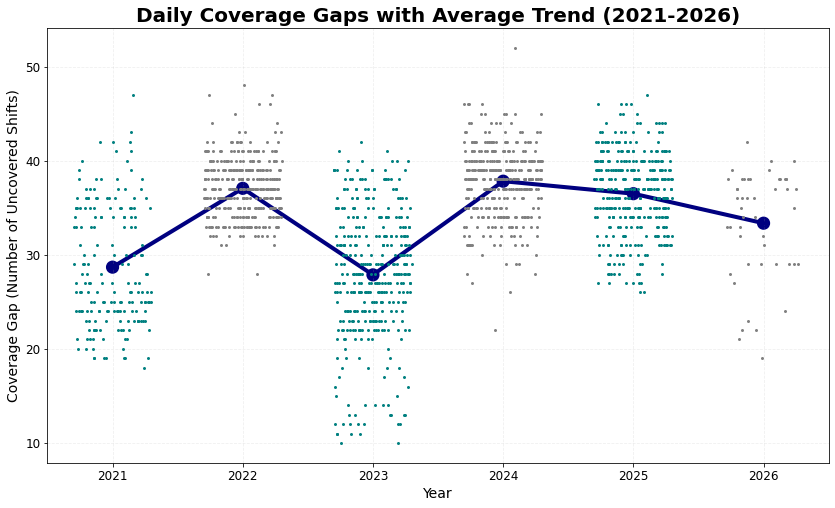

In [127]:
plt.figure(figsize=(14,8))

sns.pointplot(
    data=df, x='Year', y='Coverage_Gap', estimator='mean',
    color='navy', markers='o', scale=1.5,
    errorbar=None
)

# Manually assign colors per year for stripplot
colors_per_year = ['teal', 'gray', 'teal', 'gray', 'teal', 'gray']  # 6 years
for i, year in enumerate(sorted(df['Year'].unique())):
    sns.stripplot(
        data=df[df['Year']==year],
        x=[i]*len(df[df['Year']==year]),  # position dots at correct x
        y=df[df['Year']==year]['Coverage_Gap'],
        color=colors_per_year[i],
        size=3, jitter=0.3
    )

plt.title('Daily Coverage Gaps with Average Trend (2021-2026)', fontsize=20, fontweight='bold')
plt.xlabel('Year', fontsize=14)
plt.ylabel('Coverage Gap (Number of Uncovered Shifts)', fontsize=14)
plt.xticks(ticks=range(len(df['Year'].unique())), labels=sorted(df['Year'].unique()), fontsize=12)
plt.yticks(fontsize=12)
plt.grid(True, alpha=0.2, linestyle='--')

plt.show()

In [122]:
# Group by Year and calculate the main stats
coverage_stats = df.groupby('Year')['Coverage_Gap'].agg(
    Avg_Gap='mean',
    Std_Dev='std',
    Min_Gap='min',
    Max_Gap='max',
    Total_Days='count'  # useful if some years have missing days
).reset_index()

print(coverage_stats)

   Year    Avg_Gap   Std_Dev  Min_Gap  Max_Gap  Total_Days
0  2021  28.684783  6.359760       18       47         184
1  2022  37.057534  3.050757       28       48         365
2  2023  27.865753  6.890514       10       42         365
3  2024  37.816940  3.711786       22       52         366
4  2025  36.490411  4.277213       26       47         365
5  2026  33.354167  5.737112       19       42          48
